<a href="https://colab.research.google.com/github/aasutoshz/PESGM-2026-Tutorial-Distribution-Grid-Optimal-Power-Flow-DOPF/blob/main/branchflow_models/Lindist3flow/Lindist3flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Distribution Gird Optimal Power Flow based on LinDist3Flow Formulation
This code implements linear version of branch-flow based three-phase  Distribution Grid Optimal Power Flow (DG-OPF) formulation.


The development and implementation of this code, test network are contribution of:\
**Aashutosh Neupane**, **Florida International University (FIU), USA**

This Python code is built up on previous MATLAB live script (developed and tested on the first 20 nodes of the IEEE 123 Node Test Feeder). The contributors of the MATLAB livescripts were:

**Sumit Paudyal**, **Florida International University (FIU), USA** \
**Adedoyin Inaolaji**, **University at Buffalo, USA**\
**Anamika Dubey**, **Washington State University (WSU), USA**\
**Sukumar Kamalasadan**, **University of North Carolina at Charlotte (UNCC), USA**

If you have any questions and comments kindly email aneup003@fiu.edu


## 1. Import Required Libraries

In [ ]:
import numpy as np
import openpyxl
import os
import openpyxl
from collections import deque
from math import atan2, degrees, sqrt
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


## 2. Load the Network Data

In [ ]:
from google.colab import files
uploaded = files.upload()
excel_file = next(iter(uploaded.keys()))
script_dir = os.getcwd()

excel_file = os.path.join(script_dir, excel_file)
print(f"Reading network data from: {excel_file}")
wb = openpyxl.load_workbook(excel_file, data_only=True)


Saving 123Node_Standard.xlsx to 123Node_Standard (1).xlsx
Reading network data from: /content/123Node_Standard (1).xlsx


## 3. Read Parameters Sheet and Extract Key Parameters

In [ ]:
param_sheet = wb["Parameters"]
param_dict = {}
for row in param_sheet.iter_rows(min_row=1, values_only=True):
    if row[0] is not None:
        param_dict[str(row[0])] = row[1]

slack_bus = int(param_dict["slack_bus"])
baseMVA = float(param_dict["baseMVA_VA"])
baseV = float(param_dict["baseV"])
baseZ = baseV**2 / baseMVA
Vmin_pu = float(param_dict["Vmin_pu"])
Vmax_pu = float(param_dict["Vmax_pu"])
dg_oversize = float(param_dict["DG_oversize_factor"])
LMP = float(param_dict["LMP"])
PMP = float(param_dict["PMP"])

print(f'  Slack bus: {slack_bus}, baseMVA: {baseMVA/1e6} MVA, baseV: {baseV:.2f} V')

  Slack bus: 150, baseMVA: 1.0 MVA, baseV: 2401.78 V


## 4. Read Branches Sheet and Extract Branch Data

In [ ]:

branch_sheet = wb["Branches"]

branch_raw = []
for row in branch_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is not None:
        branch_raw.append([float(v) if v is not None else 0.0 for v in row])
branch_raw = np.array(branch_raw)
brs = branch_raw.shape[0]
node1 = branch_raw[:, 0].astype(int)
node2 = branch_raw[:, 1].astype(int)
all_buses = sorted(set(node1.tolist() + node2.tolist()))
tnode = len(all_buses)
max_bus_number = max(all_buses)

bus_to_idx = {bus: i for i, bus in enumerate(all_buses)}
print("Bus to index mapping:", bus_to_idx)


print(f'  Number of buses: {all_buses}, {tnode} (from branch data)')
print(f'  Number of branches: {branch_raw.shape}')
print(f'  Maximum bus number: {max_bus_number}')


Bus to index mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23, 25: 24, 26: 25, 27: 26, 28: 27, 29: 28, 30: 29, 31: 30, 32: 31, 33: 32, 34: 33, 35: 34, 36: 35, 37: 36, 38: 37, 39: 38, 40: 39, 41: 40, 42: 41, 43: 42, 44: 43, 45: 44, 46: 45, 47: 46, 48: 47, 49: 48, 50: 49, 51: 50, 52: 51, 53: 52, 54: 53, 55: 54, 56: 55, 57: 56, 58: 57, 59: 58, 60: 59, 61: 60, 62: 61, 63: 62, 64: 63, 65: 64, 66: 65, 67: 66, 68: 67, 69: 68, 70: 69, 71: 70, 72: 71, 73: 72, 74: 73, 75: 74, 76: 75, 77: 76, 78: 77, 79: 78, 80: 79, 81: 80, 82: 81, 83: 82, 84: 83, 85: 84, 86: 85, 87: 86, 88: 87, 89: 88, 90: 89, 91: 90, 92: 91, 93: 92, 94: 93, 95: 94, 96: 95, 97: 96, 98: 97, 99: 98, 100: 99, 101: 100, 102: 101, 103: 102, 104: 103, 105: 104, 106: 105, 107: 106, 108: 107, 109: 108, 110: 109, 111: 110, 112: 111, 113: 112, 114: 113, 135: 114, 149: 115, 150: 116, 151: 117, 152: 118, 160: 

## 5. Build R, X Arrays and Load Data

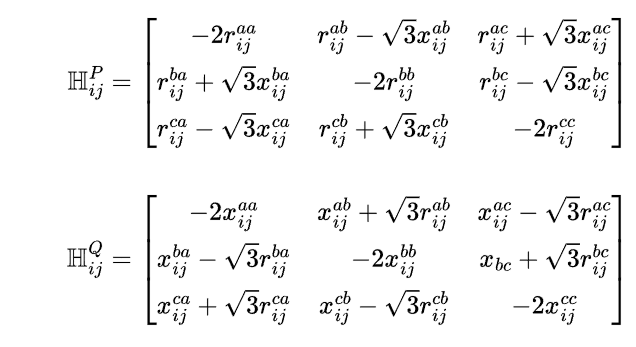

In [ ]:
# Build 3x3xbrs R and X arrays (per-unitized)
Rval = np.zeros((3, 3, brs))
Xval = np.zeros((3, 3, brs))
HP = np.zeros((3, 3, brs))
HQ = np.zeros((3, 3, brs))


for brid in range(brs):

    Rval[:, :, brid] = np.array([
        [branch_raw[brid, 2],  branch_raw[brid, 3],  branch_raw[brid, 4]],
        [branch_raw[brid, 3],  branch_raw[brid, 5],  branch_raw[brid, 6]],
        [branch_raw[brid, 4],  branch_raw[brid, 6],  branch_raw[brid, 7]],
    ]) / baseZ
    Xval[:, :, brid] = np.array([
        [branch_raw[brid, 8],  branch_raw[brid, 9],  branch_raw[brid, 10]],
        [branch_raw[brid, 9],  branch_raw[brid, 11], branch_raw[brid, 12]],
        [branch_raw[brid, 10], branch_raw[brid, 12], branch_raw[brid, 13]],
    ]) / baseZ

    r, x = Rval[:,:,brid], Xval[:,:,brid]
    HP[:,:,brid] = np.array([
        [-2*r[0,0],                    r[0,1]-np.sqrt(3)*x[0,1],   r[0,2]+np.sqrt(3)*x[0,2]],
        [ r[1,0]+np.sqrt(3)*x[1,0],  -2*r[1,1],                    r[1,2]-np.sqrt(3)*x[1,2]],
        [ r[2,0]-np.sqrt(3)*x[2,0],   r[2,1]+np.sqrt(3)*x[2,1],  -2*r[2,2]                 ],
    ])
    HQ[:,:,brid] = np.array([
        [-2*x[0,0],                    x[0,1]+np.sqrt(3)*r[0,1],   x[0,2]-np.sqrt(3)*r[0,2]],
        [ x[1,0]-np.sqrt(3)*r[1,0],  -2*x[1,1],                    x[1,2]+np.sqrt(3)*r[1,2]],
        [ x[2,0]+np.sqrt(3)*r[2,0],   x[2,1]-np.sqrt(3)*r[2,1],  -2*x[2,2]                 ],])



## 6. Load Sheet Data (Loads, DG)

In [ ]:

############################
# 3. Read Loads sheet -> Pload, Qload arrays
############################
load_sheet = wb["Loads"]


Pload = np.zeros((tnode, 3))
Qload = np.zeros((tnode, 3))

for row in load_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])
    idx = bus_to_idx[bus]
    Pload[idx, 0] = LMP * float(row[1]) * 1000 / baseMVA
    Pload[idx, 1] = LMP * float(row[2]) * 1000 / baseMVA
    Pload[idx, 2] = LMP * float(row[3]) * 1000 / baseMVA
    Qload[idx, 0] = LMP * float(row[4]) * 1000 / baseMVA
    Qload[idx, 1] = LMP * float(row[5]) * 1000 / baseMVA
    Qload[idx, 2] = LMP * float(row[6]) * 1000 / baseMVA
    print(f'Bus {bus}: Pload = {Pload[idx]}, Qload = {Qload[idx]}, idx = {idx}')

############################
# 4. Read DG sheet -> PPv array
############################

dg_sheet=wb["DG"]
PPv = np.zeros((tnode, 3))

for row in dg_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])
    idx = bus_to_idx[bus]
    PPv[idx, 0] = PMP * float(row[1]) * 1000 / baseMVA
    PPv[idx, 1] = PMP * float(row[2]) * 1000 / baseMVA
    PPv[idx, 2] = PMP * float(row[3]) * 1000 / baseMVA
    print(f'Bus {bus}: PPv = {PPv[idx]}, idx = {idx}')

Sinv = PPv * dg_oversize
Qinv = np.sqrt(Sinv**2 - PPv**2)


Bus 1: Pload = [0.04 0.   0.  ], Qload = [0.02 0.   0.  ], idx = 0
Bus 2: Pload = [0.   0.02 0.  ], Qload = [0.   0.01 0.  ], idx = 1
Bus 4: Pload = [0.   0.   0.04], Qload = [0.   0.   0.02], idx = 3
Bus 5: Pload = [0.   0.   0.02], Qload = [0.   0.   0.01], idx = 4
Bus 6: Pload = [0.   0.   0.04], Qload = [0.   0.   0.02], idx = 5
Bus 7: Pload = [0.02 0.   0.  ], Qload = [0.01 0.   0.  ], idx = 6
Bus 9: Pload = [0.04 0.   0.  ], Qload = [0.02 0.   0.  ], idx = 8
Bus 10: Pload = [0.02 0.   0.  ], Qload = [0.01 0.   0.  ], idx = 9
Bus 11: Pload = [0.04 0.   0.  ], Qload = [0.02 0.   0.  ], idx = 10
Bus 12: Pload = [0.   0.02 0.  ], Qload = [0.   0.01 0.  ], idx = 11
Bus 16: Pload = [0.   0.   0.04], Qload = [0.   0.   0.02], idx = 15
Bus 17: Pload = [0.   0.   0.02], Qload = [0.   0.   0.01], idx = 16
Bus 19: Pload = [0.04 0.   0.  ], Qload = [0.02 0.   0.  ], idx = 18
Bus 20: Pload = [0.04 0.   0.  ], Qload = [0.02 0.   0.  ], idx = 19
Bus 22: Pload = [0.   0.04 0.  ], Qload = [0.   0

In [ ]:
print("Total P load =", np.sum(Pload) * baseMVA/1000)
print("Total Q load =", np.sum(Qload) * baseMVA/1000)
print("Total PV  (2230 KW) =", np.sum(PPv) * baseMVA/1000)

Total P load = 3490.0
Total Q load = 1920.0
Total PV  (2230 KW) = 8225.0


## 7. Build Topology

In [ ]:

phase_avail = {bus: [] for bus in all_buses}

phase_avail[slack_bus] = [1, 2, 3]

queue = deque([slack_bus])
visited = {slack_bus}

while queue:
    bus = queue.popleft()
    for brid in range(brs):
        if node1[brid] == bus:
            child = node2[brid]
            if child not in visited:
                visited.add(child)
                br_phases = [p for p in range(1, 4)
                             if Rval[p-1, p-1, brid] > 1e-10 or Xval[p-1, p-1, brid] > 1e-10]
                phase_avail[child] = sorted(set(phase_avail[bus]) & set(br_phases))
                queue.append(child)

max_out = max(np.sum(node1 == bus) for bus in all_buses)
incbr = np.zeros(tnode, dtype=int)
outbr = np.zeros((tnode, max_out), dtype=int)

for bus in all_buses:
    idx = bus_to_idx[bus]
    in_idxs = np.where(node2 == bus)[0]
    incbr[idx] = (in_idxs[0] + 1) if len(in_idxs) > 0 else 0
    print(f'Bus {bus}: Incoming branch indices: {incbr[idx]}')
    out_idxs = np.where(node1 == bus)[0]
    for col, oidx in enumerate(out_idxs):
        outbr[idx, col] = oidx + 1
    print(f'Bus {bus}: Outgoing branch indices: {outbr[idx,:len(out_idxs)]}')




Bus 1: Incoming branch indices: 2
Bus 1: Outgoing branch indices: [3 4 5]
Bus 2: Incoming branch indices: 3
Bus 2: Outgoing branch indices: []
Bus 3: Incoming branch indices: 4
Bus 3: Outgoing branch indices: [6 7]
Bus 4: Incoming branch indices: 6
Bus 4: Outgoing branch indices: []
Bus 5: Incoming branch indices: 7
Bus 5: Outgoing branch indices: [8]
Bus 6: Incoming branch indices: 8
Bus 6: Outgoing branch indices: []
Bus 7: Incoming branch indices: 5
Bus 7: Outgoing branch indices: [9]
Bus 8: Incoming branch indices: 9
Bus 8: Outgoing branch indices: [10 11 14]
Bus 9: Incoming branch indices: 11
Bus 9: Outgoing branch indices: [12]
Bus 10: Incoming branch indices: 15
Bus 10: Outgoing branch indices: []
Bus 11: Incoming branch indices: 13
Bus 11: Outgoing branch indices: []
Bus 12: Incoming branch indices: 10
Bus 12: Outgoing branch indices: []
Bus 13: Incoming branch indices: 14
Bus 13: Outgoing branch indices: [16 17 21]
Bus 14: Incoming branch indices: 12
Bus 14: Outgoing branch in

In [ ]:
print("Data loaded successfully.")
for bus in all_buses:
    print(f"  Bus {bus} → phases {[p for p in phase_avail[bus]]}")

# ═══════════════════════════════════════════════════════════════════════════════
# Determine the phase dimension for each bus
# ═══════════════════════════════════════════════════════════════════════════════
nph = {bus: len(phase_avail[bus]) for bus in all_buses}
print("\nPhase availability per bus:",nph)

# For each branch, determine the relevant phases (from the child bus)
branch_phases = {brid: phase_avail[node2[brid]] for brid in range(brs)}
print("\nBranch phases (based on child bus):",branch_phases)

connections = set()

for brid in range(brs):
    from_bus = node1[brid]
    to_bus = node2[brid]

    connections.add((from_bus, to_bus))

# print nicely
for u, v in sorted(connections):
    print(f"{u} → {v}")

Data loaded successfully.
  Bus 1 → phases [1, 2, 3]
  Bus 2 → phases [2]
  Bus 3 → phases [3]
  Bus 4 → phases [3]
  Bus 5 → phases [3]
  Bus 6 → phases [3]
  Bus 7 → phases [1, 2, 3]
  Bus 8 → phases [1, 2, 3]
  Bus 9 → phases [1]
  Bus 10 → phases [1]
  Bus 11 → phases [1]
  Bus 12 → phases [2]
  Bus 13 → phases [1, 2, 3]
  Bus 14 → phases [1]
  Bus 15 → phases [3]
  Bus 16 → phases [3]
  Bus 17 → phases [3]
  Bus 18 → phases [1, 2, 3]
  Bus 19 → phases [1]
  Bus 20 → phases [1]
  Bus 21 → phases [1, 2, 3]
  Bus 22 → phases [2]
  Bus 23 → phases [1, 2, 3]
  Bus 24 → phases [3]
  Bus 25 → phases [1, 2, 3]
  Bus 26 → phases [1, 3]
  Bus 27 → phases [1, 3]
  Bus 28 → phases [1, 2, 3]
  Bus 29 → phases [1, 2, 3]
  Bus 30 → phases [1, 2, 3]
  Bus 31 → phases [3]
  Bus 32 → phases [3]
  Bus 33 → phases [1]
  Bus 34 → phases [3]
  Bus 35 → phases [1, 2, 3]
  Bus 36 → phases [1, 2]
  Bus 37 → phases [1]
  Bus 38 → phases [2]
  Bus 39 → phases [2]
  Bus 40 → phases [1, 2, 3]
  Bus 41 → phase

## 8. Problem Formulation of Lindist3flow

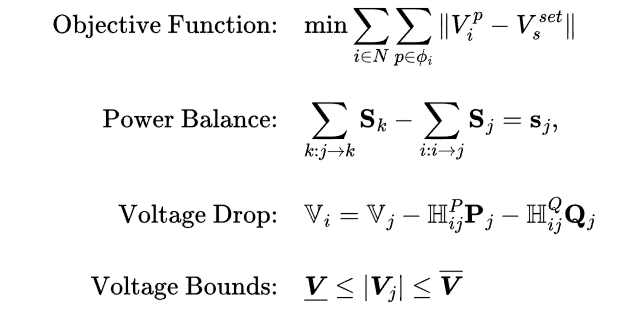![alt text](https://github.com/aasutoshz/Distribution-Grid-Optimal-Power-Flow-Models-DOPF/blob/main/branchflow_models/Lindist3flow/lindist3flow.png?raw=1)

## 9. Build and Solve Lindsit3flow DOPF Model

In [ ]:

def build_and_solve(fix_spv=False):

    Vnom  = 1.0
    Vinit = np.full((tnode, 3), Vnom**2)
    V      = cp.Variable((tnode, 3))
    Sbr_r  = cp.Variable((brs, 3))
    Sbr_i  = cp.Variable((brs, 3))
    SSlack_r = cp.Variable(3)
    SSlack_i = cp.Variable(3)
    SPv    = cp.Variable((tnode, 3))
    aux    = cp.Variable((tnode, 3), nonneg=True)

    constraints = []

    # Slack bus voltage
    slack_idx = bus_to_idx[slack_bus]
    for p in range(3):
        constraints.append(V[slack_idx, p] == Vinit[slack_idx, p])

    # Nodal power balance
    for nid in range(tnode):
        inc = incbr[nid]
        out = [o-1 for o in outbr[nid] if o != 0]

        if inc == 0:   # slack
            for p in range(3):
                constraints.append(SSlack_r[p] == cp.sum(Sbr_r[out, p]))
                constraints.append(SSlack_i[p] == cp.sum(Sbr_i[out, p]))
        elif not out:  # leaf
            b = inc - 1
            for p in range(3):
                rhs_r = Pload[nid,p] - PPv[nid,p]
                rhs_i = Qload[nid,p] - SPv[nid,p]
                constraints.append(Sbr_r[b, p] == rhs_r)
                constraints.append(Sbr_i[b, p] == rhs_i)
        else:          # intermediate
            b = inc - 1
            for p in range(3):
                constraints.append(Sbr_r[b,p] == cp.sum(Sbr_r[out, p]) + Pload[nid,p] - PPv[nid,p])
                constraints.append(Sbr_i[b,p] == cp.sum(Sbr_i[out, p]) + Qload[nid,p] - SPv[nid,p])

        # Inverter reactive limits
        for p in range(3):
            constraints.append(SPv[nid, p] >= -Qinv[nid, p])
            constraints.append(SPv[nid, p] <=  Qinv[nid, p])

        # Voltage bounds
        for p in range(3):
            constraints.append(V[nid, p] >= 0.95**2)
            constraints.append(V[nid, p] <= 1.05**2)

    # Voltage drop per branch: V[n1,:] = V[n2,:] - Sbr_r*HP - Sbr_i*HQ  (row-vec * matrix)
    for brid in range(brs):
        n1 = bus_to_idx[node1[brid]]
        n2 = bus_to_idx[node2[brid]]
        for p in range(3):
            drop = sum(Sbr_r[brid,k]*HP[k,p,brid] + Sbr_i[brid,k]*HQ[k,p,brid] for k in range(3))
            constraints.append(V[n1, p] == V[n2, p] - drop)

    # Fix SPv = 0 for base case
    if fix_spv:
        constraints.append(SPv == 0)

    # L1 objective
    constraints.append(aux >= V - Vnom)
    constraints.append(aux >= Vnom - V)
    objective = cp.Minimize(cp.sum(aux))

    optimization = cp.Problem(objective, constraints)
    optimization.solve(solver=cp.HIGHS, verbose=False)
    print(f"  Status: {optimization.status}  |  Objective: {optimization.value:.6f}")

    # Extract phase-aware voltages (phase_avail uses 1-indexed phases [1,2,3])
    Vraw = V.value
    Vval = np.full((tnode, 3), np.nan)
    for bus, phases in phase_avail.items():
        nid = bus_to_idx[bus]
        for ph in phases:
            p = ph - 1   # convert 1-indexed phase to 0-indexed
            Vval[nid, p] = np.sqrt(abs(Vraw[nid, p]))

    return Vval, optimization.value


## 10 SOLVE AND EXTRACT VALUES USING DG CONTROL

In [ ]:

# ─────────────────────────────────────────────────────────────
# 8. SOLVE BOTH SCENARIOS
# ─────────────────────────────────────────────────────────────
print("Solving OPF with DG reactive power control...")
Vval_control, Obj_control = build_and_solve(fix_spv=False)
# ─────────────────────────────────────────────────────────────
# 9. PRINT RESULTS
# ─────────────────────────────────────────────────────────────
def print_voltages(Vval, title):
    print(f"\n=== {title} ===")
    print(f"{'Bus':<6}{'Va':<10}{'Vb':<10}{'Vc':<10}")
    print("-" * 36)
    for nid in range(tnode):
        def fmt(v): return f"{v:.4f}" if not np.isnan(v) else "  -   "
        print(f"{nid+1:<6}{fmt(Vval[nid,0]):<10}{fmt(Vval[nid,1]):<10}{fmt(Vval[nid,2]):<10}")

print_voltages(Vval_control,   "WITH DG CONTROL")

Solving OPF with DG reactive power control...
  Status: optimal  |  Objective: 1.466788

=== WITH DG CONTROL ===
Bus   Va        Vb        Vc        
------------------------------------
1     1.0023    0.9984    0.9981    
2       -       0.9982      -       
3       -         -       1.0005    
4       -         -       1.0000    
5       -         -       1.0015    
6       -         -       1.0026    
7     1.0009    1.0003    0.9986    
8     1.0000    1.0016    0.9988    
9     1.0008      -         -       
10    1.0030      -         -       
11    1.0052      -         -       
12      -       1.0013      -       
13    1.0014    0.9997    1.0014    
14    1.0033      -         -       
15      -         -       1.0012    
16      -         -       1.0021    
17      -         -       1.0008    
18    1.0001    1.0000    1.0011    
19    0.9988      -         -       
20    0.9980      -         -       
21    1.0006    0.9998    1.0008    
22      -       0.9985      -       

In [ ]:
# Save the "with DG control" voltages to Excel

output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_ctrl = os.path.join(output_dir, "Voltage with DG Control (Lindist3flow).xlsx")
wb_out_ctrl = openpyxl.Workbook()
ws_out_ctrl = wb_out_ctrl.active
ws_out_ctrl.title = "With_DG_Control"

ws_out_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for bus in all_buses:
    idx = all_buses.index(bus)
    row_vals = [bus]
    for ph in range(3):
        v = Vval_control[idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 6)))
    ws_out_ctrl.append(row_vals)

wb_out_ctrl.save(excel_out_ctrl)
print(f"Saved Excel file: {excel_out_ctrl}")

Saved Excel file: /content/Voltage with DG Control (Lindist3flow).xlsx


## 11. SOLVE AND SAVE VALUE WITHOUT DG CONTROL

In [ ]:

print("Solving base case (no DG reactive power control)...")
Vval_nocontrol, Obj_nocontrol = build_and_solve(fix_spv=True)

print_voltages(Vval_nocontrol, "BASE CASE (NO DG CONTROL)")

Solving base case (no DG reactive power control)...
  Status: optimal  |  Objective: 9.176321

=== BASE CASE (NO DG CONTROL) ===
Bus   Va        Vb        Vc        
------------------------------------
1     1.0017    1.0009    1.0009    
2       -       1.0007      -       
3       -         -       1.0084    
4       -         -       1.0079    
5       -         -       1.0140    
6       -         -       1.0186    
7     1.0012    1.0051    0.9986    
8     1.0010    1.0079    0.9970    
9     1.0064      -         -       
10    1.0172      -         -       
11    1.0244      -         -       
12      -       1.0076      -       
13    0.9984    1.0100    0.9970    
14    1.0175      -         -       
15      -         -       0.9994    
16      -         -       1.0042    
17      -         -       0.9990    
18    1.0019    1.0119    0.9949    
19    1.0006      -         -       
20    0.9997      -         -       
21    1.0054    1.0133    0.9943    
22      -       1.01

In [ ]:
# Save the "without DG control" voltages to Excel

output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_no_ctrl = os.path.join(output_dir, "Voltage without DG Control (Lindist3flow).xlsx")
wb_out_no_ctrl = openpyxl.Workbook()
ws_out_no_ctrl = wb_out_no_ctrl.active
ws_out_no_ctrl.title = "Without_DG_Control"

ws_out_no_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for bus in all_buses:
    idx = all_buses.index(bus)
    row_vals = [bus]
    for ph in range(3):
        v = Vval_nocontrol[idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 6)))
    ws_out_no_ctrl.append(row_vals)

wb_out_no_ctrl.save(excel_out_no_ctrl)
print(f"Saved Excel file: {excel_out_no_ctrl}")

Saved Excel file: /content/Voltage without DG Control (Lindist3flow).xlsx


## 12. Plot Results

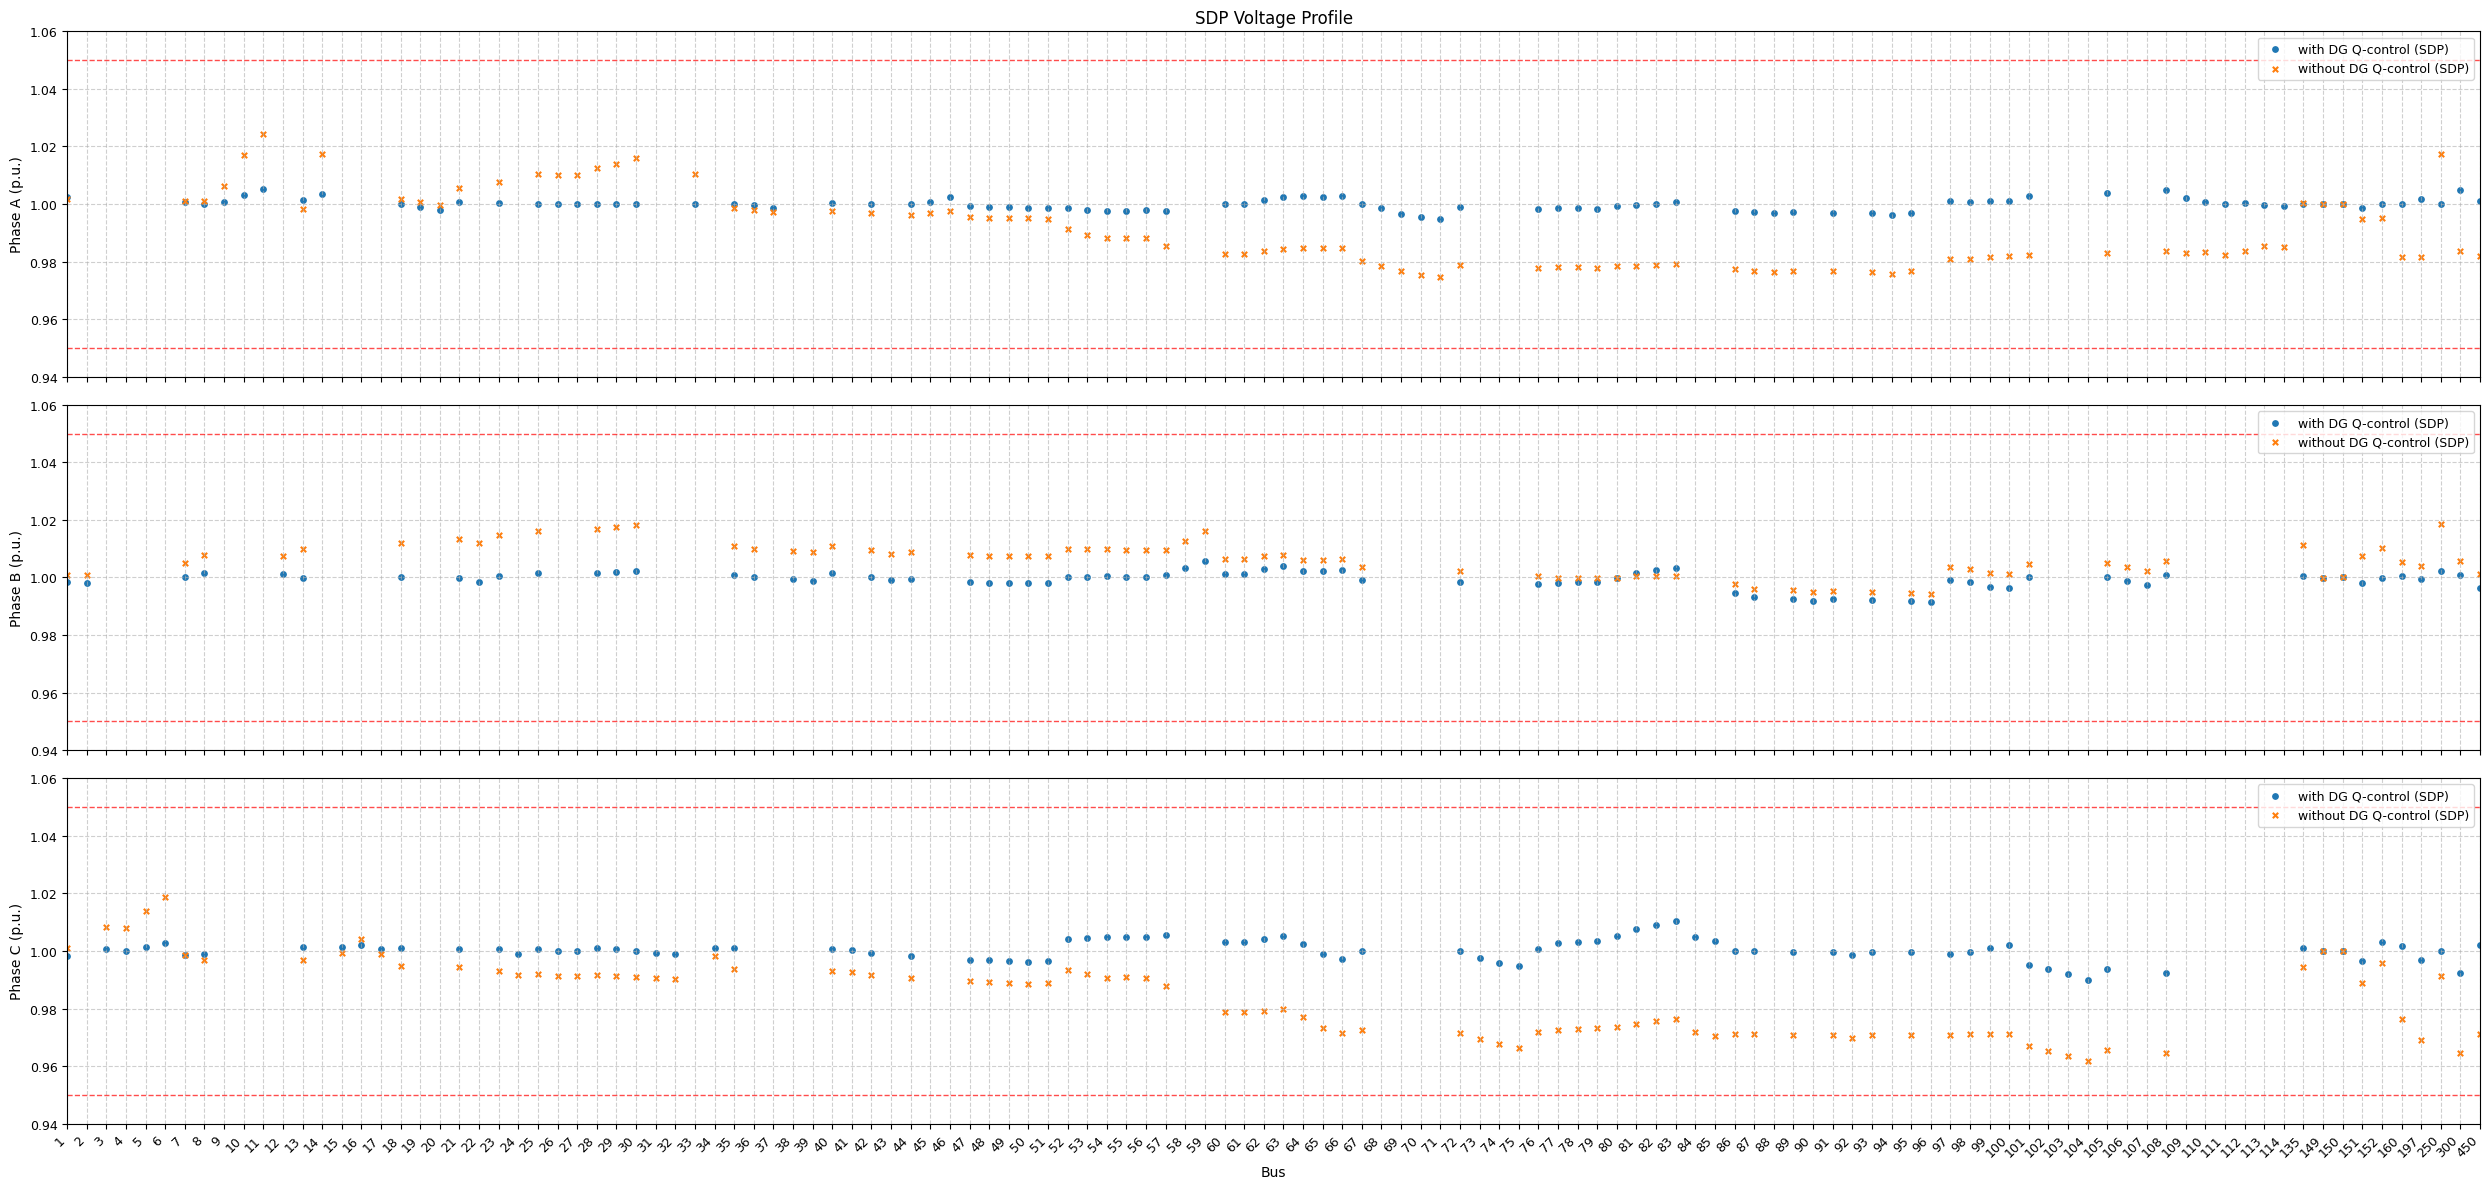

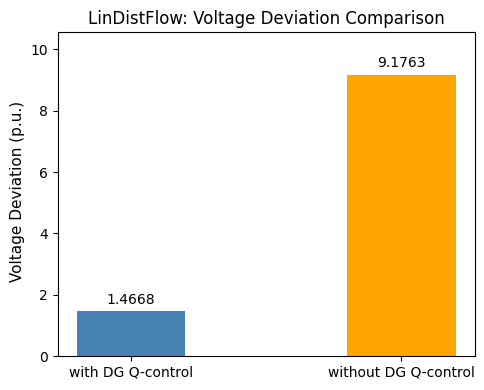

In [ ]:
# Plot voltage profiles and loss comparison
buses = idx
x_labels = list(all_buses)
x_pos = np.arange(len(x_labels))
fig, axes = plt.subplots(3, 1, figsize=(25, 12), sharex=True)
phase_labels = ["Phase A", "Phase B", "Phase C"]

for idx_phase, ax in enumerate(axes):
    ax.scatter(x_pos, Vval_control[:, idx_phase], marker='o', s=15, label="with DG Q-control (SDP)")
    ax.scatter(x_pos, Vval_nocontrol[:, idx_phase], marker='x', s=15, label="without DG Q-control (SDP)")

    ax.set_ylabel(f"{phase_labels[idx_phase]} (p.u.)")
    ax.set_xlim(0, len(x_labels) - 1)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.legend(loc="upper right", fontsize=9)
    ax.tick_params(labelsize=9)
    ax.set_ylim(0.94, 1.06)
    ax.horizontal_line = ax.axhline(0.95, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.horizontal_line = ax.axhline(1.05, color='red', linestyle='--', linewidth=1, alpha=0.7)

    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel("Bus")
axes[0].set_title("SDP Voltage Profile")
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "sdp_voltage_profile.png"), dpi=300)
plt.show()


fig2, ax2 = plt.subplots(figsize=(5, 4))
obj_vals = [Obj_control, Obj_nocontrol]

bars = ax2.bar(["with DG Q-control", "without DG Q-control"], obj_vals,
               width=0.4, color=["steelblue", "orange"])
ax2.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax2.set_ylabel(" Voltage Deviation (p.u.)", fontsize=11)
ax2.set_title("LinDistFlow: Voltage Deviation Comparison")
ax2.set_ylim(0, max(obj_vals) * 1.15)
ax2.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig(r"lindistflow_obj_comparison.png", dpi=300)
plt.show()
